# Анализ работы солвера RPML

Этот ноутбук предназначен для:
1. Проверки работы ядра солвера (`core/rpml`).
2. Выбора и загрузки любого инстанса из набора данных Rios-Solis.
3. Полноценного анализа результатов работы солвера (MILP) в сравнении с базовыми стратегиями (Avalanche, Snowball).
4. Наглядного представления результатов в виде графиков и диаграмм, включая анализ балансов и платежей для избежания ложных выводов.

In [1]:
# %pip install -q ipywidgets matplotlib seaborn plotly

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display, Markdown

from rpml.data_loader import load_instance
from rpml.milp_model import RPMLModel
from rpml.baseline import debt_avalanche, debt_snowball

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Выбор инстанса
Выберите инстанс из выпадающего списка ниже. Список формируется из директории `RiosSolisDataset/Instances/Instances`.

In [2]:
instances_dir = Path("RiosSolisDataset/Instances/Instances")
if not instances_dir.exists():
    instances_dir = Path("../RiosSolisDataset/Instances/Instances")
    
instance_files = sorted(
    f.name for f in instances_dir.glob("*.dat") if "Deudas_12" not in f.name
)

if not instance_files:
    print(f"Инстансы не найдены в {instances_dir.absolute()}")
else:
    instance_dropdown = widgets.Dropdown(
        options=instance_files,
        value=instance_files[0] if instance_files else None,
        description='Инстанс:',
        disabled=False,
        layout=widgets.Layout(width='50%')
    )
    display(instance_dropdown)

Dropdown(description='Инстанс:', layout=Layout(width='50%'), options=('Deudas_4_0_0_0_4_120_fijo_fijo_0.dat', …

## 2. Запуск солвера и базовых алгоритмов
Загружаем выбранный инстанс, запускаем MILP модель и базовые стратегии (Avalanche, Snowball).

In [3]:
selected_file = instance_dropdown.value
instance_path = instances_dir / selected_file

print(f"Загрузка инстанса: {selected_file}")
instance = load_instance(instance_path)

print(f"Параметры: {instance.n} кредитов, горизонт {instance.T} месяцев, начальный долг: {instance.total_debt:,.2f}")

print("\nЗапуск MILP солвера (лимит 60 секунд)...")
model = RPMLModel(instance, time_limit_seconds=60)
milp_solution = model.solve()
print(f"Статус MILP: {milp_solution.status}, Время: {milp_solution.solve_time:.2f} сек, Целевая функция (выплаты): {milp_solution.objective_value:,.2f}")

print("\nЗапуск базовых стратегий...")
avalanche_solution = debt_avalanche(instance)
print(f"Avalanche: Общая стоимость: {avalanche_solution.total_cost:,.2f}")

snowball_solution = debt_snowball(instance)
print(f"Snowball: Общая стоимость: {snowball_solution.total_cost:,.2f}")

if milp_solution.status == "OPTIMAL":
    ava_savings = (avalanche_solution.total_cost - milp_solution.objective_value) / avalanche_solution.total_cost * 100
    snow_savings = (snowball_solution.total_cost - milp_solution.objective_value) / snowball_solution.total_cost * 100
    display(Markdown(f"**Экономия MILP vs Avalanche:** {ava_savings:.2f}%"))
    display(Markdown(f"**Экономия MILP vs Snowball:** {snow_savings:.2f}%"))
elif milp_solution.status == "FEASIBLE":
    display(Markdown("⚠️ **ВНИМАНИЕ:** Найдено допустимое решение, но оно **не доказано как оптимальное** (статус FEASIBLE). Сравнение экономии может быть некорректным."))
else:
    display(Markdown(f"❌ **ОШИБКА:** MILP не нашел допустимого решения. Статус: {milp_solution.status}"))

Загрузка инстанса: Deudas_4_0_0_2_2_120_fijo_fijo_3.dat
Параметры: 4 кредитов, горизонт 120 месяцев, начальный долг: 399,788.91

Запуск MILP солвера (лимит 60 секунд)...
Running HiGHS 1.11.0 (git hash: 364c83a5): Copyright (c) 2025 HiGHS under MIT licence terms
Статус MILP: OPTIMAL, Время: 0.08 сек, Целевая функция (выплаты): 611,017.29

Запуск базовых стратегий...
Avalanche: Общая стоимость: 629,975.84
Snowball: Общая стоимость: 673,118.59


**Экономия MILP vs Avalanche:** 3.01%

**Экономия MILP vs Snowball:** 9.23%

## 3. Автоматическая проверка корректности
Чтобы избежать ложных выводов, программно проверяем, что модель не нарушает логику (нет отрицательных балансов, не превышен бюджет, все долги закрыты).

In [4]:
if milp_solution.status == "OPTIMAL":
    print("--- Проверка корректности решения MILP ---")
    
    # 1. Проверка финального баланса
    final_balances = milp_solution.balances[:, -1]
    max_final_balance = np.max(final_balances)
    if max_final_balance > 1e-4:
        print(f"⚠️ ВНИМАНИЕ: Не все долги погашены до конца горизонта! Макс. остаток: {max_final_balance:.4f}")
    else:
        print("✅ Все долги успешно погашены к концу горизонта.")
        
    # 2. Проверка отрицательных балансов
    if np.any(milp_solution.balances < -1e-4):
        print("⚠️ ВНИМАНИЕ: обнаружены отрицательные балансы (модель переплатила)!")
    else:
        print("✅ Отрицательных балансов нет.")
        
    # 3. Проверка бюджетного ограничения
    T = instance.T
    payments_sum = np.sum(milp_solution.payments, axis=0)
    savings = milp_solution.savings
    prev_savings = np.zeros(T)
    prev_savings[1:] = savings[:-1]
    
    available_funds = instance.monthly_income + prev_savings
    used_funds = payments_sum + savings
    
    budget_violations = np.where(used_funds > available_funds + 1e-4)[0]
    if len(budget_violations) > 0:
        print(f"⚠️ ВНИМАНИЕ: нарушение бюджета в месяцах: {budget_violations}")
    else:
        print("✅ Бюджетные ограничения соблюдены во всех месяцах.")

--- Проверка корректности решения MILP ---
✅ Все долги успешно погашены к концу горизонта.
✅ Отрицательных балансов нет.
✅ Бюджетные ограничения соблюдены во всех месяцах.


## 4. Визуализация результатов
Сравнение общей стоимости, динамики выплат и остатков. Графики строятся **только** если найдено оптимальное решение.

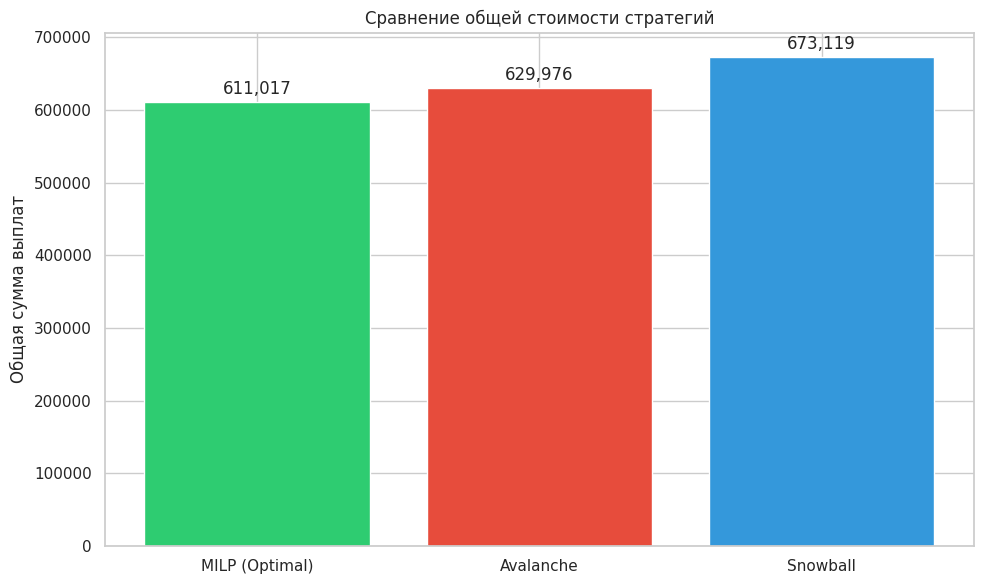

In [5]:
def plot_total_cost_comparison(milp_val, ava_val, snow_val):
    labels = ['MILP (Optimal)', 'Avalanche', 'Snowball']
    costs = [milp_val, ava_val, snow_val]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(labels, costs, color=['#2ecc71', '#e74c3c', '#3498db'])
    
    ax.set_ylabel('Общая сумма выплат')
    ax.set_title('Сравнение общей стоимости стратегий')
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

if milp_solution.status == "OPTIMAL":
    plot_total_cost_comparison(milp_solution.objective_value, avalanche_solution.total_cost, snowball_solution.total_cost)

In [6]:
def plot_interactive_budget(instance, sol, title, max_month=None):
    T = instance.T if max_month is None else max_month
    months = np.arange(T)
    
    payments = np.sum(sol.payments[:, :T], axis=0)
    savings = sol.savings[:T]
    
    prev_savings = np.zeros(T)
    if T > 1:
        prev_savings[1:] = sol.savings[:T-1]
    available = instance.monthly_income[:T] + prev_savings
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=months, y=payments, name='Платежи по долгам',
        marker_color='#e74c3c', opacity=0.8
    ))
    fig.add_trace(go.Bar(
        x=months, y=savings, name='Перенос в сбережения',
        marker_color='#2ecc71', opacity=0.8
    ))
    
    fig.add_trace(go.Scatter(
        x=months, y=available, name='Доступные средства',
        mode='lines+markers', line=dict(color='black', width=2),
        marker=dict(size=6)
    ))
    
    fig.update_layout(
        title=title,
        xaxis_title='Месяц',
        yaxis_title='Сумма (у.е.)',
        barmode='stack',
        hovermode='x unified',
        template='plotly_white',
        height=500
    )
    
    return fig

def get_last_active_month(sol):
    total_b = np.sum(sol.balances, axis=0)
    active_months = np.where(total_b > 1e-4)[0]
    return active_months[-1] if len(active_months) > 0 else 0

if milp_solution.status == "OPTIMAL":
    last_m_milp = get_last_active_month(milp_solution)
    last_m_ava = get_last_active_month(avalanche_solution)
    last_m_snow = get_last_active_month(snowball_solution)
    
    plot_max_month = min(instance.T, max(last_m_milp, last_m_ava, last_m_snow) + 3)
    
    out_milp = widgets.Output()
    out_ava = widgets.Output()
    out_snow = widgets.Output()
    
    tab = widgets.Tab(children=[out_milp, out_ava, out_snow])
    tab.set_title(0, 'MILP (solver)')
    tab.set_title(1, 'Avalanche')
    tab.set_title(2, 'Snowball')
    
    display(tab)
    
    with out_milp:
        fig_milp = plot_interactive_budget(instance, milp_solution, 'Использование бюджета (MILP)', plot_max_month)
        fig_milp.show()
        
    with out_ava:
        fig_ava = plot_interactive_budget(instance, avalanche_solution, 'Использование бюджета (Avalanche)', plot_max_month)
        fig_ava.show()
        
    with out_snow:
        fig_snow = plot_interactive_budget(instance, snowball_solution, 'Использование бюджета (Snowball)', plot_max_month)
        fig_snow.show()


**Почему MILP перестает копить сбережения, а базовые алгоритмы копят их бесконечно?**
* **MILP (солвер):** в математической модели ограничение бюджета задано как неравенство: `Платежи + Сбережения <= Доход + Сбережения_с_прошлого_месяца`. Цель солвера — минимизировать общие выплаты. У него нет стимула максимизировать итоговые сбережения. Поэтому, как только все долги погашены, солвер просто перестает переносить остатки в сбережения (ему это не нужно для оптимизации целевой функции).
* **Avalanche / Snowball:** базовые алгоритмы работают жадно. Их логика: `Сбережения = Доход + Сбережения_с_прошлого_месяца - Платежи`. Они автоматически отправляют в сбережения **все** неиспользованные средства. Поэтому после погашения долгов их сбережения растут линейно до конца горизонта $T$.

### 4.1. Структура выплат по кредитам на всем горизонте

Ниже добавлена интерактивная визуализация в духе фронтенда. Можно выбрать стратегию и окно агрегации (`1`, `3`, `6`, `12` месяцев), чтобы увидеть:
- стековую столбчатую диаграмму абсолютных выплат по кредитам;
- 100% стековую диаграмму долей выплат по кредитам в каждом интервале;
- итоговую столбчатую диаграмму нагрузки по кредитам за весь горизонт.

In [7]:
LOAN_COLORS = ['#3b82f6', '#8b5cf6', '#ec4899', '#10b981', '#f59e0b', '#14b8a6', '#ef4444', '#6366f1']

STRATEGY_SOLUTIONS = {
    'milp': milp_solution,
    'avalanche': avalanche_solution,
    'snowball': snowball_solution,
}

STRATEGY_LABELS = {
    'milp': 'MILP (solver)',
    'avalanche': 'Avalanche',
    'snowball': 'Snowball',
}

WINDOW_OPTIONS = [
    ('1 месяц', 1),
    ('3 месяца', 3),
    ('6 месяцев', 6),
    ('12 месяцев', 12),
]


def build_interval_labels(horizon, window):
    labels = []
    for start in range(0, horizon, window):
        end = min(start + window, horizon)
        labels.append(f'{start + 1}' if window == 1 else f'{start + 1}-{end}')
    return labels


def aggregate_payments_by_window(sol, horizon, window):
    payments = np.asarray(sol.payments[:, :horizon], dtype=float)
    starts = list(range(0, horizon, window))
    aggregated = np.zeros((payments.shape[0], len(starts)))

    for idx, start in enumerate(starts):
        end = min(start + window, horizon)
        aggregated[:, idx] = payments[:, start:end].sum(axis=1)

    return build_interval_labels(horizon, window), aggregated


def build_loan_labels(n_loans):
    return [f'Кредит {idx + 1}' for idx in range(n_loans)]


def plot_payment_mix_dashboard(strategy_key='milp', window=12):
    sol = STRATEGY_SOLUTIONS[strategy_key]
    loan_names = build_loan_labels(instance.n)
    labels, aggregated = aggregate_payments_by_window(sol, instance.T, window)

    interval_totals = aggregated.sum(axis=0)
    loan_totals = aggregated.sum(axis=1)
    shares = np.divide(
        aggregated,
        interval_totals,
        out=np.zeros_like(aggregated),
        where=interval_totals > 1e-9,
    ) * 100

    leading_idx = int(np.argmax(loan_totals))
    display(Markdown(
        f"**{STRATEGY_LABELS[strategy_key]}**. Горизонт: `{instance.T}` мес., окно агрегации: `{window}` мес. "
        f"Суммарные выплаты: `{loan_totals.sum():,.0f}`. "
        f"Максимальная нагрузка приходится на `{loan_names[leading_idx]}`: `{loan_totals[leading_idx]:,.0f}`."
    ))

    absolute_fig = go.Figure()
    for idx, loan_name in enumerate(loan_names):
        absolute_fig.add_trace(go.Bar(
            x=labels,
            y=aggregated[idx],
            name=loan_name,
            marker_color=LOAN_COLORS[idx % len(LOAN_COLORS)],
            customdata=shares[idx],
            hovertemplate=(
                '<b>%{fullData.name}</b><br>'
                'Интервал: %{x}<br>'
                'Выплаты: %{y:,.0f}<br>'
                'Доля в интервале: %{customdata:.1f}%<extra></extra>'
            ),
        ))

    absolute_fig.update_layout(
        title=f'{STRATEGY_LABELS[strategy_key]}: абсолютные выплаты по кредитам',
        barmode='stack',
        template='plotly_white',
        height=480,
        xaxis_title='Интервал месяцев',
        yaxis_title='Сумма выплат',
        legend_title='Кредиты',
        hovermode='x unified',
    )
    absolute_fig.update_xaxes(type='category')
    absolute_fig.show()

    share_fig = go.Figure()
    for idx, loan_name in enumerate(loan_names):
        share_fig.add_trace(go.Bar(
            x=labels,
            y=shares[idx],
            name=loan_name,
            marker_color=LOAN_COLORS[idx % len(LOAN_COLORS)],
            customdata=aggregated[idx],
            hovertemplate=(
                '<b>%{fullData.name}</b><br>'
                'Интервал: %{x}<br>'
                'Доля: %{y:.1f}%<br>'
                'Выплаты: %{customdata:,.0f}<extra></extra>'
            ),
            showlegend=False,
        ))

    share_fig.update_layout(
        title=f'{STRATEGY_LABELS[strategy_key]}: доли выплат по кредитам',
        barmode='stack',
        template='plotly_white',
        height=420,
        xaxis_title='Интервал месяцев',
        yaxis_title='Доля выплат, %',
        hovermode='x unified',
    )
    share_fig.update_xaxes(type='category')
    share_fig.update_yaxes(range=[0, 100], ticksuffix='%')
    share_fig.show()

    order = np.argsort(loan_totals)[::-1]
    ordered_names = [loan_names[idx] for idx in order]
    ordered_totals = loan_totals[order]
    ordered_colors = [LOAN_COLORS[idx % len(LOAN_COLORS)] for idx in order]

    ranking_fig = go.Figure(go.Bar(
        x=ordered_totals,
        y=ordered_names,
        orientation='h',
        marker_color=ordered_colors,
        text=[f'{value:,.0f}' for value in ordered_totals],
        textposition='outside',
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Суммарные выплаты: %{x:,.0f}<extra></extra>'
        ),
    ))
    ranking_fig.update_layout(
        title=f'{STRATEGY_LABELS[strategy_key]}: итоговая нагрузка по кредитам за весь горизонт',
        template='plotly_white',
        height=320,
        xaxis_title='Сумма выплат',
        yaxis_title='',
    )
    ranking_fig.update_yaxes(categoryorder='array', categoryarray=ordered_names[::-1])
    ranking_fig.show()


if milp_solution.status == 'OPTIMAL':
    strategy_selector = widgets.ToggleButtons(
        options=[('MILP', 'milp'), ('Avalanche', 'avalanche'), ('Snowball', 'snowball')],
        value='milp',
        description='Стратегия:',
    )
    window_selector = widgets.SelectionSlider(
        options=WINDOW_OPTIONS,
        value=12,
        description='Окно:',
        continuous_update=False,
        layout=widgets.Layout(width='70%'),
    )

    output = widgets.interactive_output(
        plot_payment_mix_dashboard,
        {'strategy_key': strategy_selector, 'window': window_selector},
    )

    display(widgets.VBox([
        strategy_selector,
        window_selector,
        output,
    ]))

## 5. Детализация по отдельным кредитам (Баланс vs Платеж)
Интерактивный график для проверки того, что платеж не превышает текущий баланс с учетом процентов. Выберите кредит из выпадающего списка.

In [8]:
def plot_interactive_loan_details(loan_idx):
    if milp_solution.status != "OPTIMAL":
        return
        
    T = instance.T
    months = np.arange(T)
    
    payments = milp_solution.payments[loan_idx, :]
    balances = milp_solution.balances[loan_idx, :]
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=months, y=payments, name='Платеж (в течение мес.)',
        marker_color='#e74c3c', opacity=0.6
    ))
    
    fig.add_trace(go.Scatter(
        x=months, y=balances, name='Баланс (на конец мес.)',
        mode='lines+markers', line=dict(color='#3498db', width=3),
        marker=dict(size=8)
    ))
    
    release_m = instance.release_time[loan_idx]
    fig.add_vline(x=release_m, line_dash="dash", line_color="gray", 
                  annotation_text=f"Выдача (мес. {release_m})", annotation_position="top right")
    
    fig.update_layout(
        title=f'Детализация по кредиту {loan_idx} (MILP)',
        xaxis_title='Месяц',
        yaxis_title='Сумма (у.е.)',
        hovermode='x unified',
        template='plotly_white',
        height=500,
        yaxis=dict(rangemode='tozero')
    )
    
    fig.show()

if milp_solution.status == "OPTIMAL":
    widgets.interact(plot_interactive_loan_details, loan_idx=widgets.IntSlider(min=0, max=instance.n-1, step=1, value=0, description='Кредит:'))


interactive(children=(IntSlider(value=0, description='Кредит:', max=3), Output()), _dom_classes=('widget-inter…

## 6. Декомпозиция стоимости или "откуда берется экономия?!"
Чтобы понять, за счет чего MILP достигает меньших выплат, мы можем разложить общую сумму платежей на 3 компонента:
1. **Тело долга (Principal):** Изначальная сумма кредита (она всегда одинакова, если долг погашен полностью).
2. **Обычные проценты (Interest):** Проценты, начисленные по базовой ставке.
3. **Штрафы (Penalties):** Штрафы за просрочку минимального платежа или за досрочное погашение (если применимо).

Часто MILP может заплатить *больше* обычных процентов, но при этом избежать огромных штрафов, в которые попадают жадные алгоритмы!

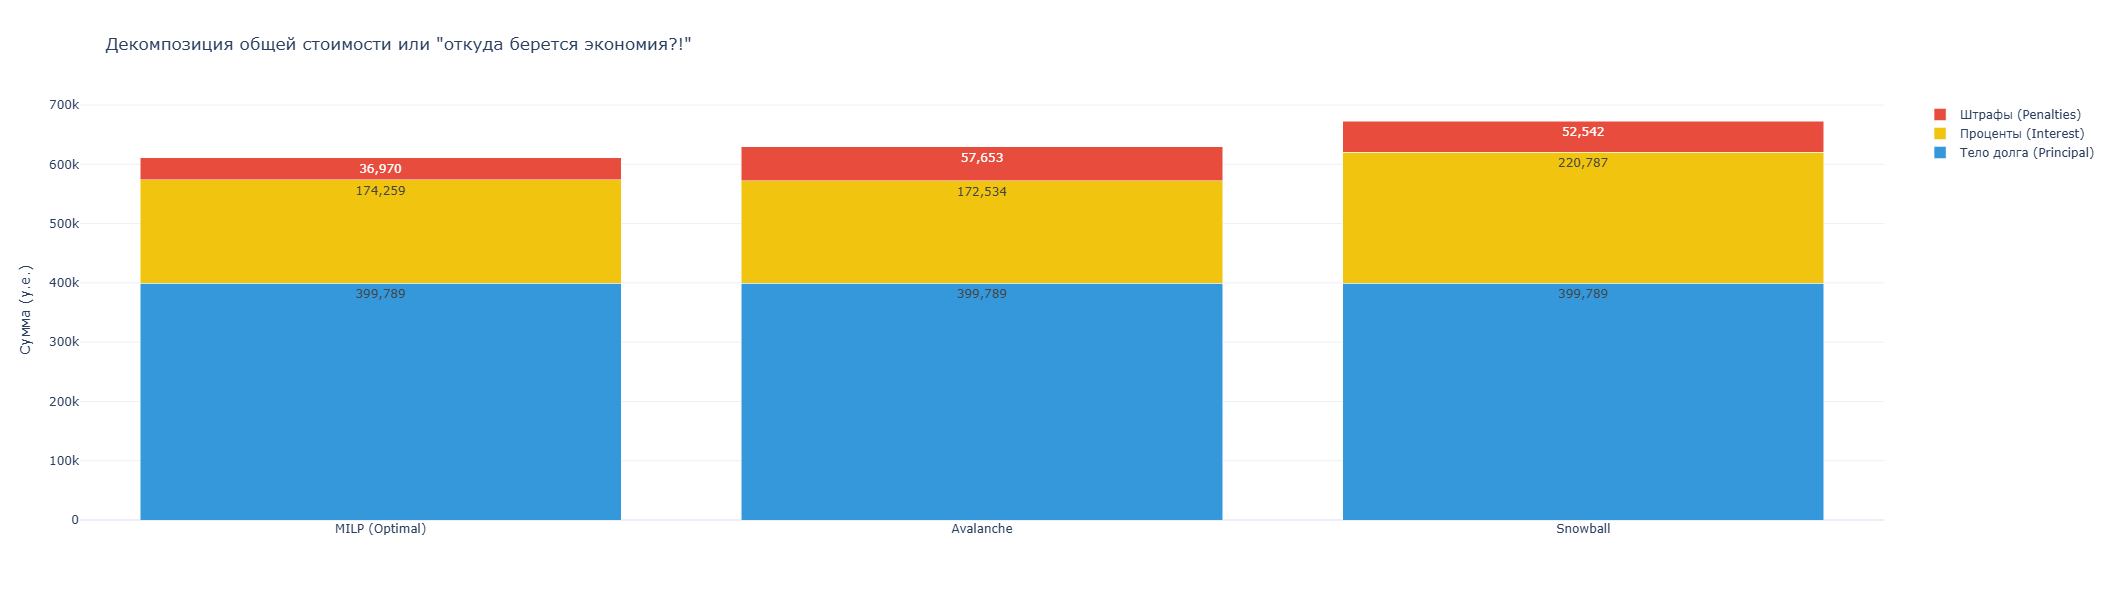

In [9]:
def decompose_payments(instance, sol):
    principal_paid = 0.0
    interest_paid = 0.0
    penalties_paid = 0.0
    
    for j in range(instance.n):
        r_j = int(instance.release_time[j])
        p_j = float(instance.principals[j])
        final_b = float(sol.balances[j, -1])
        
        ord_int_j = 0.0
        for t in range(r_j + 1, instance.T):
            prev_b = p_j if t - 1 == r_j else float(max(0.0, sol.balances[j, t-1]))
            ord_int_j += prev_b * float(instance.interest_rates[j, t])
            
        total_x = float(np.sum(sol.payments[j, :]))
        pen_j = total_x - (p_j - final_b) - ord_int_j
        
        principal_paid += (p_j - final_b)
        interest_paid += ord_int_j
        penalties_paid += max(0.0, pen_j)
        
    return principal_paid, interest_paid, penalties_paid

if milp_solution.status == "OPTIMAL":
    labels = ['MILP (Optimal)', 'Avalanche', 'Snowball']
    
    milp_p, milp_i, milp_pen = decompose_payments(instance, milp_solution)
    ava_p, ava_i, ava_pen = decompose_payments(instance, avalanche_solution)
    snow_p, snow_i, snow_pen = decompose_payments(instance, snowball_solution)
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=labels, y=[milp_p, ava_p, snow_p], name='Тело долга (Principal)',
        marker_color='#3498db', texttemplate='%{y:,.0f}', textposition='inside'
    ))
    fig.add_trace(go.Bar(
        x=labels, y=[milp_i, ava_i, snow_i], name='Проценты (Interest)',
        marker_color='#f1c40f', texttemplate='%{y:,.0f}', textposition='inside'
    ))
    fig.add_trace(go.Bar(
        x=labels, y=[milp_pen, ava_pen, snow_pen], name='Штрафы (Penalties)',
        marker_color='#e74c3c', texttemplate='%{y:,.0f}', textposition='inside'
    ))
    
    fig.update_layout(
        title='Декомпозиция общей стоимости или "откуда берется экономия?!"',
        yaxis_title='Сумма (у.е.)',
        barmode='stack',
        template='plotly_white',
        height=600
    )
    
    fig.show()

## 7. Экспорт результатов
Сохранение полных таймлайнов (MILP, Avalanche, Snowball) в JSON файл для дальнейшего анализа.

In [10]:
import json
from rpml.metrics import compare_solutions, validate_baseline_solution
from rpml.timeline_export import build_timeline_payload

if milp_solution.status in ("OPTIMAL", "FEASIBLE"):
    ava_valid, _, ava_final_bal = validate_baseline_solution(avalanche_solution, instance)
    snow_valid, _, snow_final_bal = validate_baseline_solution(snowball_solution, instance)

    comparison = compare_solutions(
        optimal=milp_solution,
        avalanche=avalanche_solution,
        snowball=snowball_solution,
        instance_name=instance.name,
        n_loans=instance.n,
        avalanche_valid=ava_valid,
        avalanche_repaid_by_T=(ava_final_bal < 1e-4),
        avalanche_final_balance=ava_final_bal,
        snowball_valid=snow_valid,
        snowball_repaid_by_T=(snow_final_bal < 1e-4),
        snowball_final_balance=snow_final_bal,
    )

    payload = build_timeline_payload(
        instance=instance,
        comparison=comparison,
        optimal_solution=milp_solution,
        avalanche_solution=avalanche_solution,
        snowball_solution=snowball_solution,
    )
    
    export_path = f"./result_samples/{instance.name}_timeline.json"
    with open(export_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    display(Markdown(f"**Результаты успешно экспортированы в файл:** `{export_path}`"))


**Результаты успешно экспортированы в файл:** `./result_samples/Deudas_4_0_0_2_2_120_fijo_fijo_3_timeline.json`